In [3]:
# ── 1. Laden & Datum konvertieren ──────────────────────────────────────
analysis_df = pd.read_excel('analysis_df.xlsx')

analysis_df['TIME'] = pd.to_datetime(
    analysis_df['TIME'].str.replace('-M', '-', regex=False),
    format='%Y-%m'
)

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOCK 1: Feature Engineering – Modell-Features
# Leakage-Regeln:
#   GS10:         Lag 1 als Minimum (Marktdaten, konservativ)
#   CPI, ER:      Lag 3 als Minimum (1–3 Monate Verzug)
#   DEBT_GDP:     Lag 12 als Minimum (12–18 Monate Verzug)
#   EXPORTS:      Lag 12 als Minimum (12–18 Monate Verzug)
# ══════════════════════════════════════════════════════════════════════════════

analysis_df = analysis_df.sort_values(['COUNTRY', 'TIME']).reset_index(drop=True)

# ── Debt/GDP ──────────────────────────────────────────────────────────────────
analysis_df['debt_gdp_lag12'] = (
    analysis_df.groupby('COUNTRY')['DEBT_GDP'].shift(12)
)
analysis_df['debt_gdp_lag24'] = (
    analysis_df.groupby('COUNTRY')['DEBT_GDP'].shift(24)
)

# Lag 1: sicherster Ansatz (1 Monat Verzug)
analysis_df['debt_gdp_change'] = (
    analysis_df.groupby('COUNTRY')['DEBT_GDP']
    .diff(12)
    .shift(1)   # DEBT_GDP_{t-1} - DEBT_GDP_{t-13}
)

analysis_df['debt_gdp_change_24'] = (
    analysis_df.groupby('COUNTRY')['DEBT_GDP'].diff(24)
    .shift(12)    # shift(12) damit auch diff(24) kein aktuelles DEBT_GDP nutzt
)

# Lag 12: konservativer Ansatz (12 Monate Verzug, Literaturstandard)
analysis_df['debt_gdp_change_lag12'] = (
    analysis_df.groupby('COUNTRY')['DEBT_GDP']
    .diff(12)
    .shift(12)  # DEBT_GDP_{t-12} - DEBT_GDP_{t-24}
)

# Prozentuale Änderung
analysis_df['debt_gdp_change_12_pct'] = (
    analysis_df['debt_gdp_change'] / analysis_df['debt_gdp_lag24']
).clip(-2, 2)

# Gelagte Dynamik
analysis_df['debt_gdp_change_lag12'] = (
    analysis_df.groupby('COUNTRY')['debt_gdp_change'].shift(12)
)

# ── Exports ───────────────────────────────────────────────────────────────────
# lag 1 change
analysis_df['export_growth'] = (
    analysis_df.groupby('COUNTRY')['EXPORTS to WORLD']
    .pct_change(12, fill_method=None)
    .shift(1)   # (EXPORTS_{t-1} - EXPORTS_{t-13}) / EXPORTS_{t-13}
    .replace([np.inf, -np.inf], np.nan)
    .clip(-5, 5)
)

analysis_df['export_lag12'] = (
    analysis_df.groupby('COUNTRY')['EXPORTS to WORLD'].shift(12)
)
analysis_df['export_lag24'] = (
    analysis_df.groupby('COUNTRY')['EXPORTS to WORLD'].shift(24)
)

# Gelagte Wachstumsrate
analysis_df['export_growth_lag12'] = (
    analysis_df.groupby('COUNTRY')['export_growth'].shift(12)
)

# ── GS10 – Lag 1 als Minimum ─────────────────────────────────────────────────
# Alle GS10-Variablen basieren auf GS10_{t-1} oder früher

# Basisvariable: GS10 mit Lag 1
analysis_df['gs10_lag1'] = (
    analysis_df.groupby('COUNTRY')['GS10'].shift(1)
)

# Änderungen: diff über gelagte Werte
# gs10_change_12 = GS10_{t-1} - GS10_{t-13}
analysis_df['gs10_change_12'] = (
    analysis_df.groupby('COUNTRY')['GS10']
    .diff(12)
    .shift(1)   # GS10_{t-1} - GS10_{t-13}
)

analysis_df['gs10_change_6'] = (
    analysis_df.groupby('COUNTRY')['gs10_lag1'].transform(
        lambda x: x.diff(6)
    )
)
analysis_df['gs10_change_3'] = (
    analysis_df.groupby('COUNTRY')['gs10_lag1'].transform(
        lambda x: x.diff(3)
    )
)
analysis_df['gs10_change_1'] = (
    analysis_df.groupby('COUNTRY')['gs10_lag1'].transform(
        lambda x: x.diff(1)
    )
)

# Prozentuale GS10-Änderungen (basieren auf gs10_lag1 als Nenner)
for suffix, diff_col in [
    ('12', 'gs10_change_12'), ('6', 'gs10_change_6'),
    ('3',  'gs10_change_3'),  ('1', 'gs10_change_1'),
]:
    analysis_df[f'gs10_change_{suffix}_pct'] = (
        analysis_df[diff_col] / analysis_df['gs10_lag1']
    ).clip(-2, 2)

# Log-Differenz: log(GS10_{t-1} / GS10_{t-13})
analysis_df['gs10_log_diff_12'] = np.log(
    analysis_df['gs10_lag1'] /
    analysis_df.groupby('COUNTRY')['gs10_lag1'].shift(12)
)

# Volatilitäts-Dummy: gs10_change_1 > rolling std
rolling_std = (
    analysis_df.groupby('COUNTRY')['gs10_change_1']
    .transform(lambda x: x.rolling(36, min_periods=6).std())
)
analysis_df['gs10_std_dummy'] = (
    analysis_df['gs10_change_1'] > rolling_std
).astype(int)

# Asymmetrische Schocks
analysis_df['gs10_increase_12'] = (
    analysis_df['gs10_change_12'].clip(lower=0)
)
analysis_df['gs10_decrease_12'] = (
    analysis_df['gs10_change_12'].clip(upper=0).abs()
)

# ── CPI – Lag 3 als Minimum ───────────────────────────────────────────────────
for lag in [3, 6, 12, 24]:
    col = f'cpi{lag}'
    analysis_df[col] = (
        analysis_df.groupby('COUNTRY')['cpi'].shift(lag)
    )
    p99 = analysis_df[col].quantile(0.99)
    analysis_df[col] = analysis_df[col].clip(upper=p99)

# CPI-Wachstumsrate: cpi{t-3} vs. cpi{t-15}
analysis_df['cpi_change_12'] = (
    (analysis_df['cpi3'] - analysis_df['cpi12'])  # beide bereits gelaggt
    / analysis_df['cpi12'].abs()
).replace([np.inf, -np.inf], np.nan).clip(-2, 2)

# ── ER – Lag 3 als Minimum ────────────────────────────────────────────────────
for lag in [3, 6, 12, 24]:
    col = f'er_rate{lag}'
    analysis_df[col] = (
        analysis_df.groupby('COUNTRY')['er_rate'].shift(lag)
    )
    p99 = analysis_df[col].quantile(0.99)
    p01 = analysis_df[col].quantile(0.01)
    analysis_df[col] = analysis_df[col].clip(p01, p99)

# ── Log-Transformation: Export-Niveau ────────────────────────────────────────
# Exporte in absoluten Zahlen sind stark rechtsschief
# log1p(x) = log(1+x) → funktioniert auch wenn x=0
analysis_df['export_lag12_log'] = np.log1p(
    analysis_df['export_lag12'].clip(lower=0)
)
analysis_df['export_lag24_log'] = np.log1p(
    analysis_df['export_lag24'].clip(lower=0)
)

# ── Log-Transformation: CPI-Niveau ───────────────────────────────────────────
# CPI kann sehr groß sein (Hyperinflation), log glättet das
for lag in [3, 6, 12, 24]:
    col     = f'cpi{lag}'
    col_log = f'cpi{lag}_log'
    analysis_df[col_log] = np.log1p(
        analysis_df[col].clip(lower=0)
    )

# ── Log-Transformation: ER – nur wenn sinnvoll ───────────────────────────────
# Nach Clipping auf p01/p99 ist er_rate bereits weniger verzerrt
# Zusätzlich log-transformiert für Robustheit
for lag in [3, 6, 12, 24]:
    col     = f'er_rate{lag}'
    col_log = f'er_rate{lag}_log'
    # Nur wenn positive Werte vorliegen (nach Clipping)
    if analysis_df[col].min() > 0:
        analysis_df[col_log] = np.log(analysis_df[col])
    else:
        analysis_df[col_log] = np.log1p(
            analysis_df[col].clip(lower=0)
        )

# ── Kontrolle ─────────────────────────────────────────────────────────────────
log_cols = [c for c in analysis_df.columns if c.endswith('_log')]
print(f"Log-transformierte Variablen: {len(log_cols)}")
for col in log_cols:
    orig = col.replace('_log', '')
    if orig in analysis_df.columns:
        print(f"  {orig:<25} Skew vorher: "
              f"{analysis_df[orig].skew():>7.2f}  "
              f"nachher: {analysis_df[col].skew():>7.2f}")

# ── Interaktionsterme ─────────────────────────────────────────────────────────
# GS10-Schock × Verschuldungsniveau (beide gelaggt → kein Leakage)
analysis_df['gs10_x_debt_gdp'] = (
    analysis_df['gs10_change_12'] * analysis_df['debt_gdp_lag12']
)

# Nur positive GS10-Schocks × Verschuldung (vorzeichen-robust)
analysis_df['gs10_increase_x_debt'] = (
    analysis_df['gs10_increase_12'] * analysis_df['debt_gdp_lag12']
)

# ── Inspektion ────────────────────────────────────────────────────────────────
model_features = [
    # Logit-Features (BMA-validiert)
    'debt_gdp_lag12', 'debt_gdp_change',
    'export_lag12',   'export_growth',
    'gs10_change_12', 'gs10_x_debt_gdp',
    'cpi3',           'er_rate3',
    'export_lag12_log', 'export_lag24_log',
    'cpi3_log',       'cpi6_log',
    'cpi12_log',      'cpi24_log',
    'er_rate3_log',   'er_rate6_log',
    'er_rate12_log',  'er_rate24_log',
    # Zusätzliche XGBoost-Features
    'debt_gdp_lag24', 'debt_gdp_change_24', 'debt_gdp_change_12_pct',
    'debt_gdp_change_lag12',
    'export_lag24', 'export_growth_lag12',
    'gs10_lag1', 'gs10_change_6', 'gs10_change_3', 'gs10_change_1',
    'gs10_change_12_pct', 'gs10_log_diff_12', 'gs10_std_dummy',
    'gs10_increase_12', 'gs10_decrease_12', 'gs10_increase_x_debt',
    'cpi6', 'cpi12', 'er_rate6', 'er_rate12', 'cpi_change_12',
]

print("── Block 1: Modell-Features ─────────────────────────────────")
print(f"Definierte Features: {len(model_features)}")
missing_feats = [f for f in model_features if f not in analysis_df.columns]
if missing_feats:
    print(f"⚠ Fehlende Spalten: {missing_feats}")
else:
    print("✓ Alle Features vorhanden")

print(f"\nFehlende Werte:")
print(analysis_df[model_features].isnull().sum()[
    analysis_df[model_features].isnull().sum() > 0
].to_string())

print(f"\nDefault-Länder:  "
      f"{analysis_df[analysis_df['DEFAULT']==1]['COUNTRY'].nunique()}")
print(f"Nicht-Default:   "
      f"{analysis_df[analysis_df['DEFAULT']==0]['COUNTRY'].nunique()}")

Log-transformierte Variablen: 10
  export_lag12              Skew vorher:   25.28  nachher:    0.77
  export_lag24              Skew vorher:   25.96  nachher:    0.78
  cpi3                      Skew vorher:    0.85  nachher:   -1.70
  cpi6                      Skew vorher:    0.78  nachher:   -1.70
  cpi12                     Skew vorher:    0.66  nachher:   -1.69
  cpi24                     Skew vorher:    0.40  nachher:   -1.69
  er_rate3                  Skew vorher:    9.53  nachher:    1.52
  er_rate6                  Skew vorher:    9.53  nachher:    1.53
  er_rate12                 Skew vorher:    9.53  nachher:    1.56
  er_rate24                 Skew vorher:    9.54  nachher:    1.63
── Block 1: Modell-Features ─────────────────────────────────
Definierte Features: 39
✓ Alle Features vorhanden

Fehlende Werte:
debt_gdp_lag12            45288
debt_gdp_change           45745
export_lag12              28985
export_growth             29296
gs10_change_12             2809
gs10_x_d

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOCK 2: Hilfs-Features – nicht in Logit oder XGBoost als Input
# Werden benötigt für:
#   - MATCHING_FEATURES_RF (Affinity Propagation / Donor Pool)
#   - RESIDUAL_VARS (SC-Zwilling)
#   - Visualisierung (Panel D: SC-Distanz über Zeit)
#   - Diagnoseplots (Default-Perioden markieren)
# ══════════════════════════════════════════════════════════════════════════════

# ── Für MATCHING_FEATURES_RF (Affinity Propagation) ──────────────────────────
# Niveau und kurzfristige Lags für Cluster-Bildung
analysis_df['debt_gdp_lag1'] = (
    analysis_df.groupby('COUNTRY')['DEBT_GDP'].shift(1)
)
analysis_df['export_lag1'] = (
    analysis_df.groupby('COUNTRY')['EXPORTS to WORLD'].shift(1)
)
analysis_df['export_lag6'] = (
    analysis_df.groupby('COUNTRY')['EXPORTS to WORLD'].shift(6)
)

# GS10-Lags für Matching (kurzfristig)
for lag in [1, 3, 6, 12, 24]:
    analysis_df[f'gs10_{lag}'] = (
        analysis_df.groupby('COUNTRY')['GS10'].shift(lag)
    )

# ── Für RESIDUAL_VARS (SC-Zwilling / Rolling Residuals) ──────────────────────
# Diese Variablen gehen in den SC-Fit ein, NICHT direkt ins Modell
# RESIDUAL_VARS = ["debt_gdp_change", "EXPORTS to WORLD", "er_rate", "cpi"]
# → "debt_gdp_change" bereits in Block 1 definiert
# → "EXPORTS to WORLD", "er_rate", "cpi" sind Rohdaten aus analysis_df
# → keine zusätzlichen Features nötig

# ── Für export_growth_lag1 (Visualisierung / Diagnostik) ─────────────────────
# Basiert auf lag1 und lag13 – nur für Diagnoseplot, nicht im Modell
analysis_df['export_lag13'] = (
    analysis_df.groupby('COUNTRY')['EXPORTS to WORLD'].shift(13)
)
analysis_df['export_growth_lag1'] = (
    analysis_df['export_lag1'] - analysis_df['export_lag13']
).replace([np.inf, -np.inf], np.nan)

# ── Für Diagnoseplots: debt_gdp_lag6 ─────────────────────────────────────────
# Nur für Panel D / SC-Distanz-Visualisierung
analysis_df['debt_gdp_lag6'] = (
    analysis_df.groupby('COUNTRY')['DEBT_GDP'].shift(6)
)

# ── Inspektion ────────────────────────────────────────────────────────────────
helper_features = [
    'debt_gdp_lag1', 'debt_gdp_lag6',
    'export_lag1', 'export_lag6', 'export_lag13', 'export_growth_lag1',
    'gs10_1', 'gs10_3', 'gs10_6', 'gs10_12', 'gs10_24',
]

print("── Block 2: Hilfs-Features ──────────────────────────────────")
print(f"Definierte Hilfs-Features: {len(helper_features)}")
print(f"\nVerwendungszweck:")
print("  MATCHING_FEATURES_RF:  debt_gdp_lag1, export_lag1, gs10_1–gs10_24")
print("  RESIDUAL_VARS:         DEBT_GDP, EXPORTS to WORLD, er_rate, cpi (Rohdaten)")
print("  Visualisierung:        export_growth_lag1, debt_gdp_lag6")
print()

# Gesamtübersicht
print("── Gesamtübersicht ──────────────────────────────────────────")
all_engineered = [c for c in analysis_df.columns
                  if c not in ['COUNTRY', 'TIME', 'DEFAULT',
                               'DEBT_GDP', 'EXPORTS to WORLD',
                               'GS10', 'er_rate', 'cpi',
                               'IMPORTS from WORLD']]
print(f"Gesamt engineerte Spalten: {len(all_engineered)}")
print(f"  Block 1 (Modell):        {len(model_features)}")
print(f"  Block 2 (Hilfe):         {len(helper_features)}")
print(f"\nDefault-Länder:  {analysis_df[analysis_df['DEFAULT']==1]['COUNTRY'].nunique()}")
print(f"Nicht-Default:   {analysis_df[analysis_df['DEFAULT']==0]['COUNTRY'].nunique()}")

── Block 2: Hilfs-Features ──────────────────────────────────
Definierte Hilfs-Features: 11

Verwendungszweck:
  MATCHING_FEATURES_RF:  debt_gdp_lag1, export_lag1, gs10_1–gs10_24
  RESIDUAL_VARS:         DEBT_GDP, EXPORTS to WORLD, er_rate, cpi (Rohdaten)
  Visualisierung:        export_growth_lag1, debt_gdp_lag6

── Gesamtübersicht ──────────────────────────────────────────
Gesamt engineerte Spalten: 61
  Block 1 (Modell):        39
  Block 2 (Hilfe):         11

Default-Länder:  70
Nicht-Default:   234


In [8]:
# ── Schritt 1: DEFAULT_DATABASE einlesen ─────────────────────────────────────
db = pd.read_excel('DEFAULT_DATABASE_edited.xlsx',
                   sheet_name='DATASET Defaults & Restruct.',
                   header=5)
db = db.iloc[:, 1:]
db.columns = ['case_nr','new_case','case_nr_ct','country_case','country','wdi',
               'start','end','alt_end',
               'strictly_pre','weakly_pre','post_default',
               'default_date','announcement','no_exact_start']
db = db[pd.to_numeric(db['case_nr'], errors='coerce').notna()].copy()
db['start']        = pd.to_datetime(db['start'],        errors='coerce')
db['end']          = pd.to_datetime(db['end'],           errors='coerce')
db['announcement'] = pd.to_datetime(db['announcement'], errors='coerce')
db['default_date'] = pd.to_datetime(db['default_date'], errors='coerce')

# Announcement nutzen wenn vorhanden, sonst Start
db['T0'] = db['announcement'].fillna(db['start'])
db['T0'] = db['T0'].dt.to_period('M').dt.to_timestamp()

In [9]:
# ── Schritt 2: Panel aufbauen ─────────────────────────────────────────────────
# Für jedes Event: expandiere auf monatliche Beobachtungen
panel_rows = []
for _, row in db.iterrows():
    country = str(row['country']).strip()
    t0      = row['T0']
    t_end   = row['end']

    if pd.isna(t0) or pd.isna(t_end):
        continue

    months = pd.date_range(t0, t_end, freq='MS')

    for i, m in enumerate(months):
        panel_rows.append({
            'COUNTRY':       country,
            'TIME':          m,
            'DEFAULT_DB':    1,
            'DEFAULT_ONSET': 1 if i == 0 else 0,
            'POST_DEFAULT':  int(row['post_default'] == 1),
            'STRICTLY_PRE':  int(row['strictly_pre'] == 1),
        })

default_panel = pd.DataFrame(panel_rows)

default_panel_agg = (
    default_panel
    .groupby(['COUNTRY', 'TIME'])
    .agg(
        DEFAULT_DB    = ('DEFAULT_DB',    'max'),
        DEFAULT_ONSET = ('DEFAULT_ONSET', 'max'),   # 1 wenn irgendein Event startet
        POST_DEFAULT  = ('POST_DEFAULT',  'max'),
        STRICTLY_PRE  = ('STRICTLY_PRE',  'max'),
    )
    .reset_index()
)

print(f"default_panel_agg: {len(default_panel_agg):,} Zeilen")
print(f"Länder im Panel:   {default_panel_agg['COUNTRY'].nunique()}")
print(f"Onset-Events:      {default_panel_agg['DEFAULT_ONSET'].sum()}")
print(f"Zeitraum:          {default_panel_agg['TIME'].min()} – {default_panel_agg['TIME'].max()}")


default_panel_agg: 6,606 Zeilen
Länder im Panel:   76
Onset-Events:      187
Zeitraum:          1976-03-01 00:00:00 – 2020-09-01 00:00:00


In [10]:
# ── Merge ─────────────────────────────────────────────────────────────────────
# Sicherstellen dass TIME in beiden DataFrames gleicher Typ
analysis_df['TIME'] = pd.to_datetime(analysis_df['TIME'])
default_panel_agg['TIME'] = pd.to_datetime(default_panel_agg['TIME'])

# Merge: LEFT JOIN damit alle analysis_df Zeilen erhalten bleiben
analysis_df = pd.merge(
    analysis_df,
    default_panel_agg[['COUNTRY', 'TIME',
                        'DEFAULT_DB', 'DEFAULT_ONSET',
                        'POST_DEFAULT', 'STRICTLY_PRE']],
    on    = ['COUNTRY', 'TIME'],
    how   = 'left',
)

# NaN → 0 (Länder/Monate ohne Default-Event)
analysis_df['DEFAULT_DB']    = analysis_df['DEFAULT_DB'].fillna(0).astype(int)
analysis_df['DEFAULT_ONSET'] = analysis_df['DEFAULT_ONSET'].fillna(0).astype(int)
analysis_df['POST_DEFAULT']  = analysis_df['POST_DEFAULT'].fillna(0).astype(int)
analysis_df['STRICTLY_PRE']  = analysis_df['STRICTLY_PRE'].fillna(0).astype(int)

# ── Merge-Kontrolle ───────────────────────────────────────────────────────────
print(f"\n── Merge-Kontrolle ──────────────────────────────────────────")
print(f"analysis_df Zeilen:          {len(analysis_df):,}")
print(f"DEFAULT_DB=1 Monate:         {analysis_df['DEFAULT_DB'].sum():,}")
print(f"DEFAULT_ONSET=1 Monate:      {analysis_df['DEFAULT_ONSET'].sum():,}")
print(f"Länder mit Onset:            {analysis_df[analysis_df['DEFAULT_ONSET']==1]['COUNTRY'].nunique()}")
print()

# Vergleich: alte DEFAULT-Variable vs. neue DEFAULT_DB
print("Vergleich alte vs. neue Default-Variable:")
print(f"  Alte DEFAULT=1:      {analysis_df['DEFAULT'].sum():,} Monate")
print(f"  Neue DEFAULT_DB=1:   {analysis_df['DEFAULT_DB'].sum():,} Monate")
print()

# Länder die im alten DEFAULT=1 sind aber NICHT im neuen → nicht gematchte Länder
old_default_countries = set(
    analysis_df[analysis_df['DEFAULT'] == 1]['COUNTRY'].unique()
)
new_default_countries = set(
    analysis_df[analysis_df['DEFAULT_DB'] == 1]['COUNTRY'].unique()
)
not_matched = old_default_countries - new_default_countries
if not_matched:
    print(f"Länder in alter Variable aber NICHT im Merge ({len(not_matched)}):")
    for c in sorted(not_matched):
        print(f"  {c}")
else:
    print("✓ Alle alten Default-Länder sind im Merge enthalten")
print()

# Länder im Merge aber NICHT in analysis_df → Ländernamen-Problem
only_in_db = new_default_countries - old_default_countries
if only_in_db:
    print(f"Länder nur im DEFAULT_DATABASE, nicht in alter Variable ({len(only_in_db)}):")
    for c in sorted(only_in_db):
        print(f"  {c}")



── Merge-Kontrolle ──────────────────────────────────────────
analysis_df Zeilen:          125,244
DEFAULT_DB=1 Monate:         6,606
DEFAULT_ONSET=1 Monate:      187
Länder mit Onset:            76

Vergleich alte vs. neue Default-Variable:
  Alte DEFAULT=1:      135 Monate
  Neue DEFAULT_DB=1:   6,606 Monate

Länder in alter Variable aber NICHT im Merge (3):
  Congo, Dem. Rep. (Zaire)
  Dominican Rep.
  Moldova (Gazprom debt)

Länder nur im DEFAULT_DATABASE, nicht in alter Variable (9):
  Chad
  Chile
  Greece
  Mongolia
  Morocco
  Panama (bond debt)
  St. Kitts and Nevis
  Trinidad and Tobago
  Uruguay


## Generate target variable

In [11]:
# ── Zielvariablen erstellen ───────────────────────────────────────────────────

# DEFAULT_ONSET_12M: Onset in den nächsten 12 Monaten
analysis_df = analysis_df.sort_values(['COUNTRY', 'TIME'])

analysis_df['DEFAULT_ONSET_12M'] = (
    analysis_df.groupby('COUNTRY')['DEFAULT_ONSET']
    .transform(lambda x:
        x.rolling(12, min_periods=1)
         .max()
         .shift(-12)
    )
    .fillna(0)
    .astype(int)
)

analysis_df['DEFAULT_ONSET_24M'] = (
    analysis_df.groupby('COUNTRY')['DEFAULT_ONSET']
    .transform(lambda x:
        x.rolling(24, min_periods=1)
         .max()
         .shift(-24)
    )
    .fillna(0)
    .astype(int)
)

1. BASIC STRUCTURE
  Shape:                   125,244 rows × 77 columns
  Countries:               234
  Time period:             1975-01 – 2020-12
  Months per country (avg): 535
  Months per country (min): 132
  Months per country (max): 552

2. TARGET VARIABLE — DEFAULT_ONSET_12M
  Positive months (=1):    2,130
  Rate (full sample):      1.701%
  Rate (training ≤2009):   2.062%
  Rate (test ≥2011):       0.566%
  Countries with onset:    76
  scale_pos_weight (train):47.5

3. DATA COVERAGE — MISSING VALUES
                  Non-null  Missing  Coverage%
GS10                125244        0      100.0
EXPORTS to WORLD     98911    26333       79.0
er_rate              95095    30149       75.9
cpi                  82213    43031       65.6
DEBT_GDP             82068    43176       65.5

4. MACRO SUMMARY — DEFAULT vs. NON-DEFAULT (12M window)
                  DEBT_GDP        EXPORTS to WORLD          GS10              er_rate           cpi       
                      mean median     

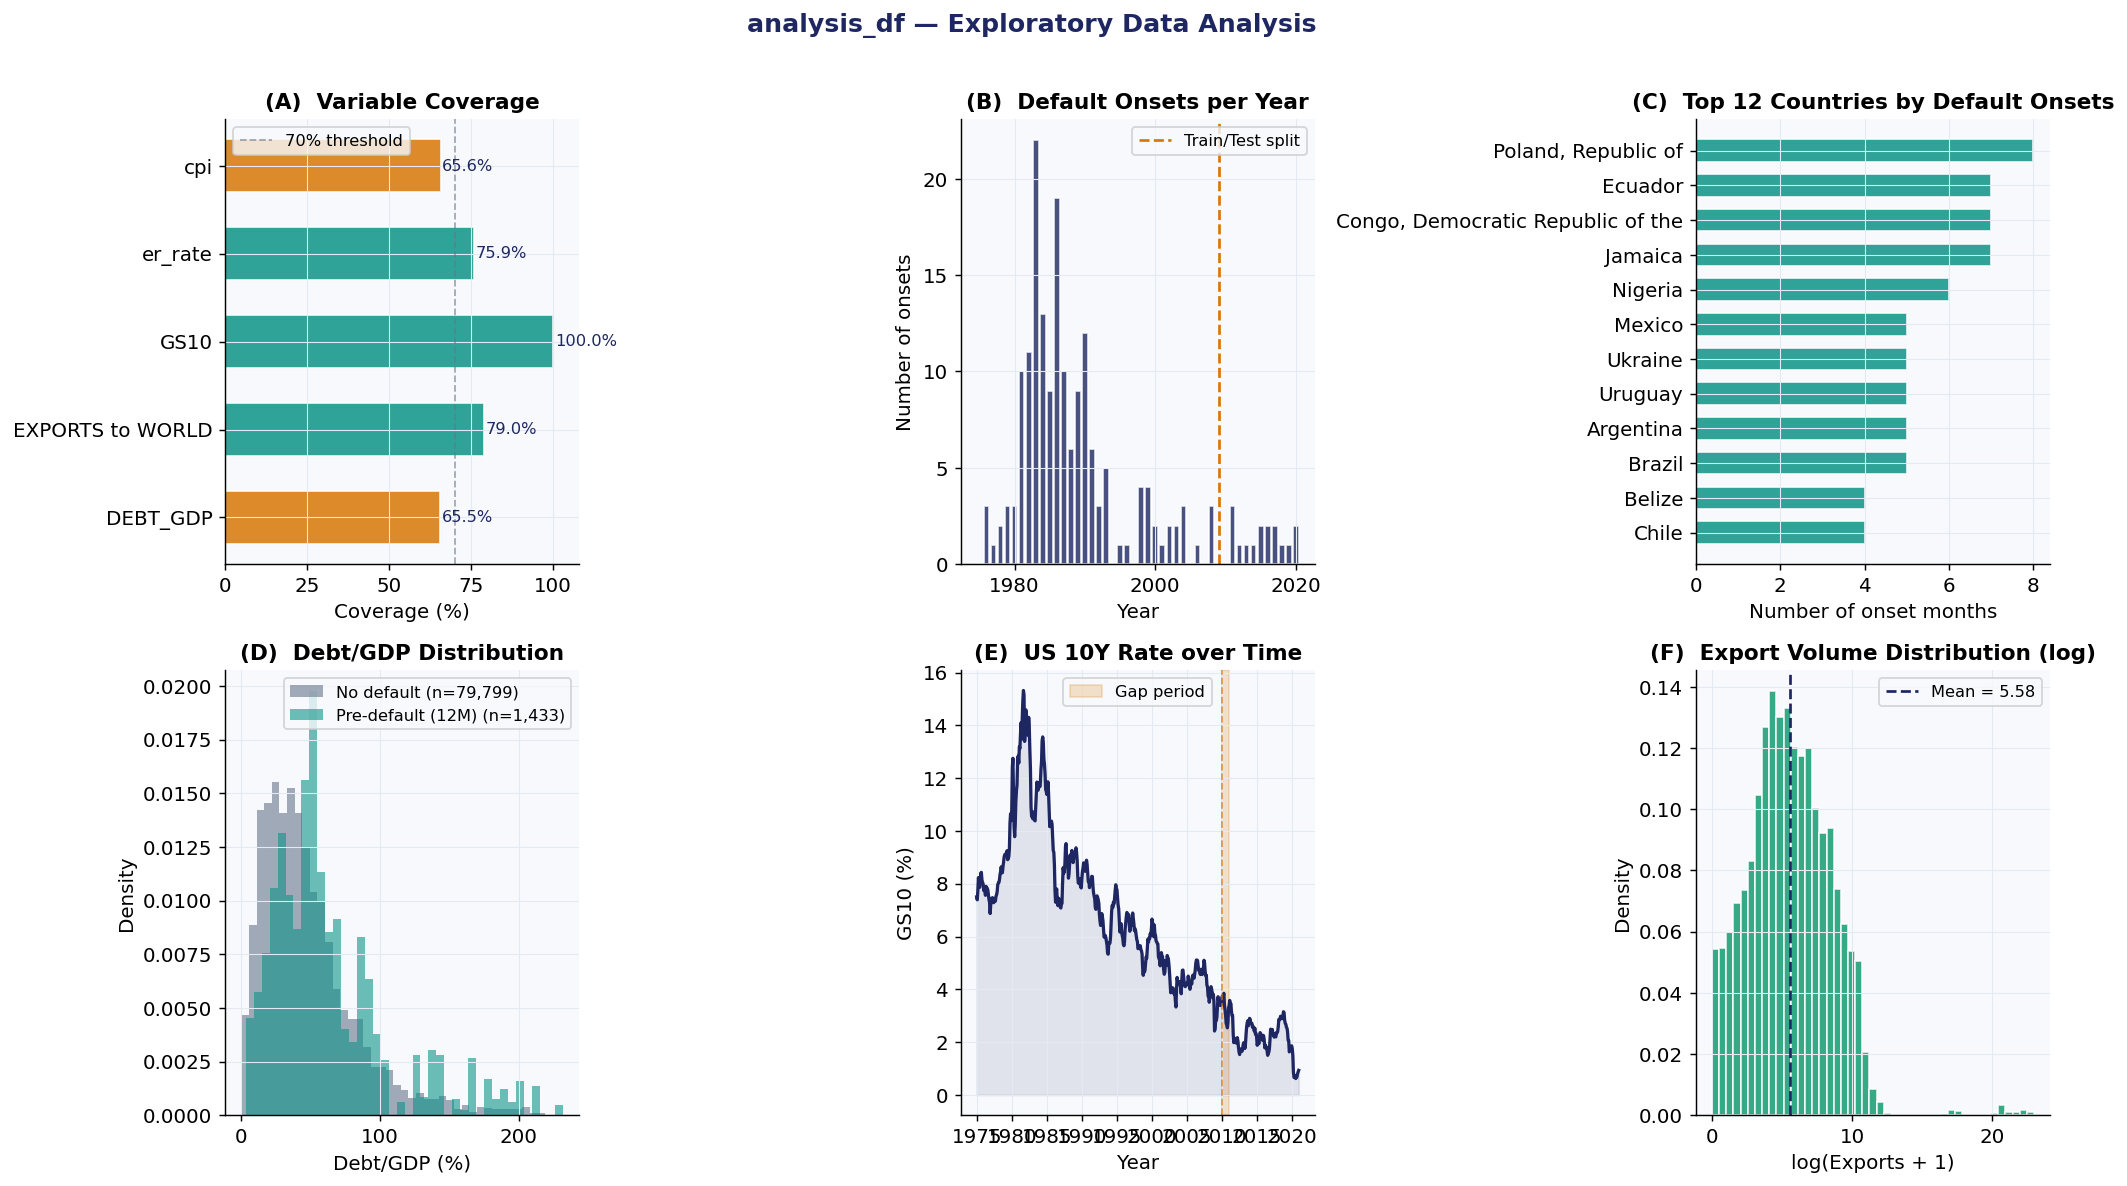

✓ Saved: eda_overview.png


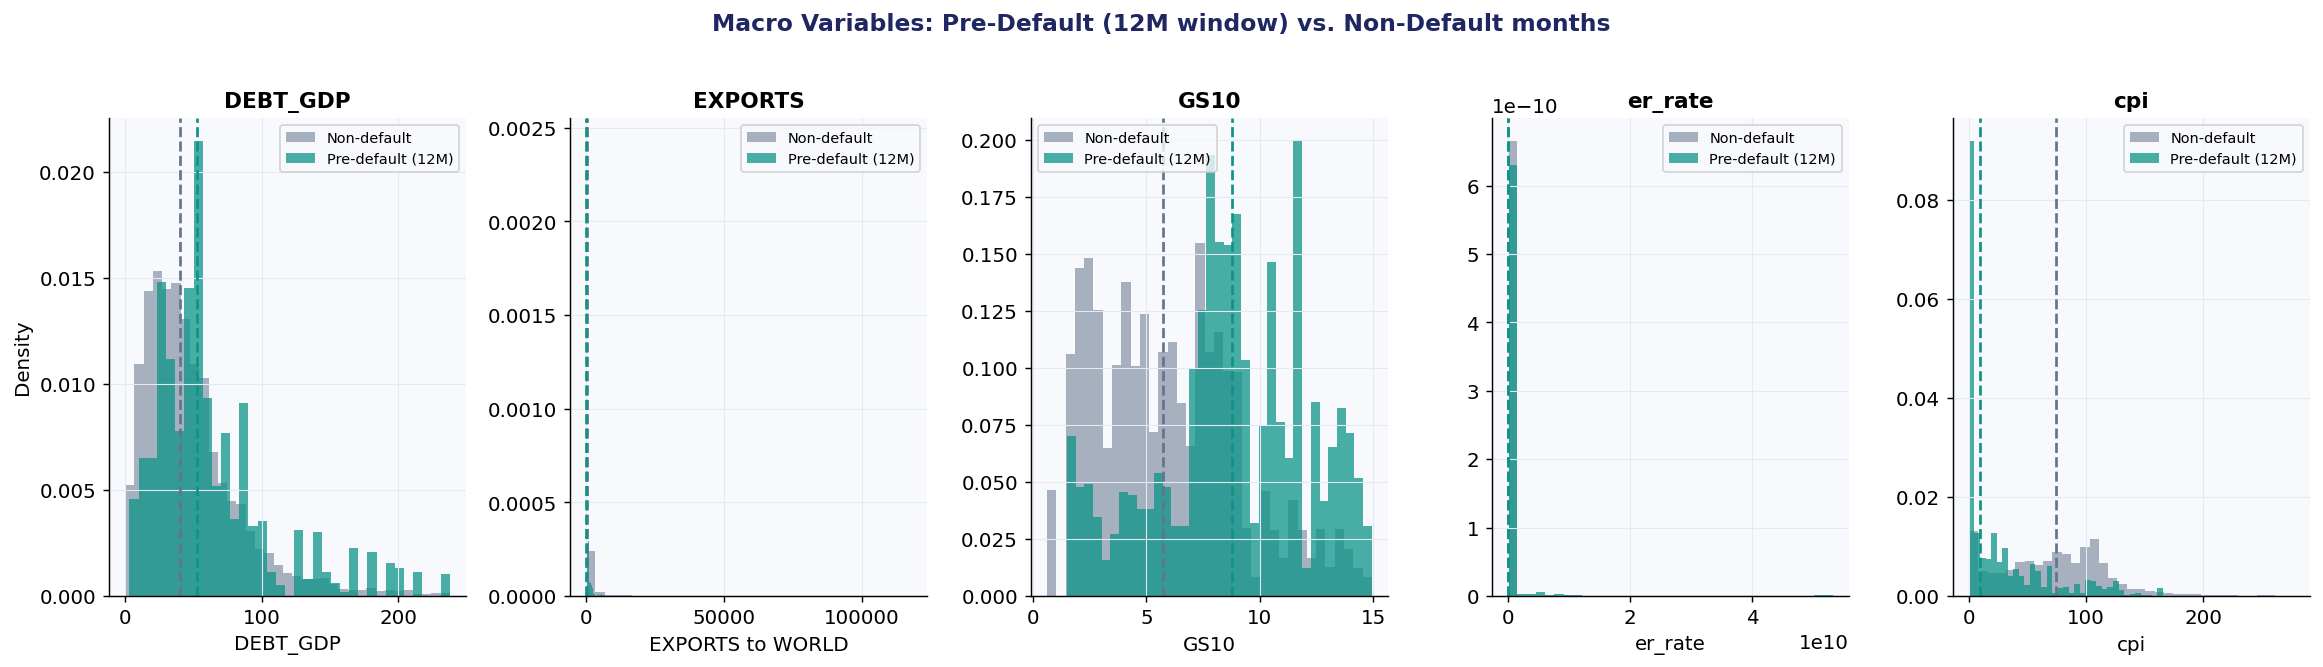

✓ Saved: eda_macro_comparison.png


In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPLORATORY DATA ANALYSIS — analysis_df
# ══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker

plt.rcParams.update({
    "figure.facecolor":   "white",
    "axes.facecolor":     "#F7F9FC",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.color":         "#E4EAF2",
    "grid.linewidth":     0.6,
    "font.family":        "sans-serif",
    "font.size":          11,
    "axes.titlesize":     12,
    "axes.titleweight":   "bold",
    "figure.dpi":         130,
})

C = {
    "navy":  "#1E2761",
    "teal":  "#0D9488",
    "slate": "#64748B",
    "amber": "#D97706",
    "red":   "#DC2626",
    "green": "#059669",
    "mid":   "#CBD5E1",
}

MACRO_VARS = ["DEBT_GDP", "EXPORTS to WORLD", "GS10", "er_rate", "cpi"]

# ── Ensure TIME is datetime ───────────────────────────────────────────────────
df = analysis_df.copy()
df["TIME"] = pd.to_datetime(df["TIME"], errors="coerce")
df["YEAR"] = df["TIME"].dt.year

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 1: Basic Structure
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("1. BASIC STRUCTURE")
print("=" * 60)
print(f"  Shape:                   {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Countries:               {df['COUNTRY'].nunique():,}")
print(f"  Time period:             {df['TIME'].min().strftime('%Y-%m')} – "
      f"{df['TIME'].max().strftime('%Y-%m')}")
print(f"  Months per country (avg): {df.groupby('COUNTRY')['TIME'].count().mean():.0f}")
print(f"  Months per country (min): {df.groupby('COUNTRY')['TIME'].count().min()}")
print(f"  Months per country (max): {df.groupby('COUNTRY')['TIME'].count().max()}")

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 2: Target Variable
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("2. TARGET VARIABLE — DEFAULT_ONSET_12M")
print("=" * 60)

target_col = "DEFAULT_ONSET_12M"
if target_col in df.columns:
    n_pos        = df[target_col].sum()
    rate_full    = df[target_col].mean()
    train_mask   = df["TIME"] <= pd.Timestamp("2009-12-01")
    test_mask    = df["TIME"] >= pd.Timestamp("2011-01-01")
    rate_train   = df.loc[train_mask, target_col].mean()
    rate_test    = df.loc[test_mask,  target_col].mean()
    n_countries  = df[df[target_col] == 1]["COUNTRY"].nunique()

    print(f"  Positive months (=1):    {int(n_pos):,}")
    print(f"  Rate (full sample):      {rate_full:.3%}")
    print(f"  Rate (training ≤2009):   {rate_train:.3%}")
    print(f"  Rate (test ≥2011):       {rate_test:.3%}")
    print(f"  Countries with onset:    {n_countries}")
    print(f"  scale_pos_weight (train):{(1 - rate_train) / rate_train:.1f}")
else:
    print("  DEFAULT_ONSET_12M not found — check column names")

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 3: Data Coverage
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("3. DATA COVERAGE — MISSING VALUES")
print("=" * 60)

coverage = pd.DataFrame({
    "Non-null":  df[MACRO_VARS].notna().sum(),
    "Missing":   df[MACRO_VARS].isna().sum(),
    "Coverage%": (df[MACRO_VARS].notna().mean() * 100).round(1),
}).sort_values("Coverage%", ascending=False)

print(coverage.to_string())

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 4: Macro Summary Statistics (Default vs. Non-Default)
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("4. MACRO SUMMARY — DEFAULT vs. NON-DEFAULT (12M window)")
print("=" * 60)

if target_col in df.columns:
    grp = df.groupby(target_col)[MACRO_VARS].agg(["mean", "median"]).round(2)
    print(grp.to_string())

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 5: Default Events per Decade
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("5. DEFAULT ONSETS PER DECADE")
print("=" * 60)

if "DEFAULT_ONSET" in df.columns:
    onsets = df[df["DEFAULT_ONSET"] == 1].copy()
    onsets["decade"] = (onsets["YEAR"] // 10 * 10).astype(str) + "s"
    dec = onsets.groupby("decade").size().rename("onsets")
    for decade, n in dec.items():
        print(f"  {decade}:  {n:>3} events")
    print(f"  Total: {dec.sum():>3} events")

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 1: Coverage + Target Distribution + Macro Distributions
# ══════════════════════════════════════════════════════════════════════════════
fig1, axes = plt.subplots(2, 3, figsize=(16, 9))
fig1.suptitle("analysis_df — Exploratory Data Analysis",
              fontsize=14, fontweight="bold", color=C["navy"], y=1.01)

# ── A: Missing value coverage ─────────────────────────────────────────────────
ax = axes[0, 0]
cov_vals = df[MACRO_VARS].notna().mean() * 100
bars = ax.barh(cov_vals.index, cov_vals.values,
               color=[C["teal"] if v >= 70 else C["amber"] if v >= 50
                      else C["red"] for v in cov_vals.values],
               alpha=0.85, edgecolor="white", height=0.6)
ax.axvline(70, color=C["slate"], lw=1, ls="--", alpha=0.6, label="70% threshold")
for bar, v in zip(bars, cov_vals.values):
    ax.text(v + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{v:.1f}%", va="center", fontsize=9, color=C["navy"])
ax.set_xlim(0, 108)
ax.set_xlabel("Coverage (%)")
ax.set_title("(A)  Variable Coverage")
ax.legend(fontsize=9)

# ── B: Default onsets over time ───────────────────────────────────────────────
ax = axes[0, 1]
if "DEFAULT_ONSET" in df.columns:
    onsets_yr = (df[df["DEFAULT_ONSET"] == 1]
                 .groupby("YEAR")
                 .size()
                 .reindex(range(1975, 2021), fill_value=0))
    ax.bar(onsets_yr.index, onsets_yr.values,
           color=C["navy"], alpha=0.8, width=0.8, edgecolor="white")
    ax.set_xlabel("Year")
    ax.set_ylabel("Number of onsets")
    ax.set_title("(B)  Default Onsets per Year")
    ax.axvline(2009, color=C["amber"], lw=1.5, ls="--",
               label="Train/Test split")
    ax.legend(fontsize=9)

# ── C: Default rate by region (top 15 countries by onset count) ───────────────
ax = axes[0, 2]
if "DEFAULT_ONSET" in df.columns:
    top_ct = (df[df["DEFAULT_ONSET"] == 1]
              .groupby("COUNTRY")
              .size()
              .sort_values(ascending=False)
              .head(12))
    ax.barh(top_ct.index[::-1], top_ct.values[::-1],
            color=C["teal"], alpha=0.85, edgecolor="white", height=0.65)
    ax.set_xlabel("Number of onset months")
    ax.set_title("(C)  Top 12 Countries by Default Onsets")

# ── D: DEBT_GDP distribution (default vs. non-default) ───────────────────────
ax = axes[1, 0]
if target_col in df.columns and "DEBT_GDP" in df.columns:
    for val, label, color in [(0, "No default", C["slate"]),
                               (1, "Pre-default (12M)", C["teal"])]:
        sub = df[df[target_col] == val]["DEBT_GDP"].dropna()
        sub = sub[sub < sub.quantile(0.99)]
        ax.hist(sub, bins=40, alpha=0.6, color=color,
                label=f"{label} (n={len(sub):,})", density=True)
    ax.set_xlabel("Debt/GDP (%)")
    ax.set_ylabel("Density")
    ax.set_title("(D)  Debt/GDP Distribution")
    ax.legend(fontsize=9)

# ── E: GS10 over time ────────────────────────────────────────────────────────
ax = axes[1, 1]
if "GS10" in df.columns:
    gs10_ts = df.groupby("TIME")["GS10"].mean().dropna()
    ax.plot(gs10_ts.index, gs10_ts.values,
            color=C["navy"], lw=1.8)
    ax.fill_between(gs10_ts.index, gs10_ts.values,
                    alpha=0.1, color=C["navy"])
    ax.axvspan(pd.Timestamp("2010-01-01"), pd.Timestamp("2011-01-01"),
               color=C["amber"], alpha=0.2, label="Gap period")
    ax.axvline(pd.Timestamp("2009-12-01"), color=C["amber"],
               lw=1, ls="--", alpha=0.7)
    ax.set_xlabel("Year")
    ax.set_ylabel("GS10 (%)")
    ax.set_title("(E)  US 10Y Rate over Time")
    ax.legend(fontsize=9)

# ── F: Export growth distribution ────────────────────────────────────────────
ax = axes[1, 2]
if "EXPORTS to WORLD" in df.columns:
    exp_log = np.log1p(df["EXPORTS to WORLD"].dropna().clip(lower=0))
    exp_log = exp_log[exp_log > 0]
    ax.hist(exp_log, bins=45, color=C["green"],
            alpha=0.8, edgecolor="white", density=True)
    ax.set_xlabel("log(Exports + 1)")
    ax.set_ylabel("Density")
    ax.set_title("(F)  Export Volume Distribution (log)")
    ax.axvline(exp_log.mean(), color=C["navy"], lw=1.5, ls="--",
               label=f"Mean = {exp_log.mean():.2f}")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()
print("✓ Saved: eda_overview.png")

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2: Macro comparison — pre-default vs. normal months
# ══════════════════════════════════════════════════════════════════════════════
if target_col in df.columns:
    fig2, axes2 = plt.subplots(1, len(MACRO_VARS), figsize=(18, 5))
    fig2.suptitle(
        "Macro Variables: Pre-Default (12M window) vs. Non-Default months",
        fontsize=13, fontweight="bold", color=C["navy"], y=1.02
    )

    for ax, var in zip(axes2, MACRO_VARS):
        grp0 = df[df[target_col] == 0][var].dropna()
        grp1 = df[df[target_col] == 1][var].dropna()

        # Clip extreme values for readability
        p99 = max(grp0.quantile(0.99), grp1.quantile(0.99))
        grp0 = grp0[grp0 <= p99]
        grp1 = grp1[grp1 <= p99]

        ax.hist(grp0, bins=35, alpha=0.55, color=C["slate"],
                label="Non-default", density=True)
        ax.hist(grp1, bins=35, alpha=0.75, color=C["teal"],
                label="Pre-default (12M)", density=True)

        ax.axvline(grp0.median(), color=C["slate"], lw=1.5, ls="--")
        ax.axvline(grp1.median(), color=C["teal"],  lw=1.5, ls="--")

        short = var.replace(" to WORLD", "").replace(" from WORLD", "")
        ax.set_title(f"{short}")
        ax.set_xlabel(var[:20])
        ax.set_ylabel("Density" if var == MACRO_VARS[0] else "")
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig("eda_macro_comparison.png", dpi=150,
                bbox_inches="tight", facecolor="white")
    plt.show()
    print("✓ Saved: eda_macro_comparison.png")